# DSC 148: NCAA March Madness: Cinderella Anomaly Detection Classifier

**Course:** DSC 148: Introduction to Data Mining,  UC San Diego \
**Instructor:** Professor Jingbo Shang  \
**By:** Janie Chan and Hannah Gonzalez


### Notebook Structure
1. [Dependencies](#1.-Dependencies)
2. [Data Loading](#2.-Data-Loading)
3. [Data Processing](#3.-Data-Processing)
4. [Exploratory Data Analysis (EDA)](#4.-Exploratory-Data-Analysis)
5. [Feature Engineering](#5.-Feature-Engineering)
6. [Models](#6.-Models)
7. [Model Tuning](#7.-Model-Tuning)
8. [Final Model](#8.-Final-Model)
9. [Conclusion](#9.-Conclusion)

---

## 1. Dependencies

In [24]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve


# Class imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('All dependencies loaded successfully.')

All dependencies loaded successfully.


---

## 2. Data Loading

We use the **Kaggle March Machine Learning Mania 2026** dataset. The five files below cover all NCAA Division I men's basketball data from 1985 through the present.

| File | Description |
|---|---|
| `MRegularSeasonCompactResults.csv` | Game-by-game regular season results (scores, location) |
| `MRegularSeasonDetailedResults.csv` | Box scores with shooting, rebounds, turnovers, etc. |
| `MNCAATourneySeeds.csv` | Tournament seed assignments per team per season |
| `MNCAATourneyCompactResults.csv` | Game-by-game tournament results |
| `MMasseyOrdinals.csv` | Third-party ranking systems (KenPom, Sagarin, etc.) |

Citation of Kaggle Dataset:
Jeff Sonas, Martyna Plomecka, Yao Yan, and Addison Howard. March Machine Learning Mania 2026. https://kaggle.com/competitions/march-machine-learning-mania-2026, 2026. Kaggle.

In [2]:
DATA_DIR = 'march-machine-learning-mania-2026/'

df_regular  = pd.read_csv(DATA_DIR + 'MRegularSeasonCompactResults.csv')
df_detailed = pd.read_csv(DATA_DIR + 'MRegularSeasonDetailedResults.csv')
df_seeds    = pd.read_csv(DATA_DIR + 'MNCAATourneySeeds.csv')
df_tourney  = pd.read_csv(DATA_DIR + 'MNCAATourneyCompactResults.csv')
df_massey   = pd.read_csv(DATA_DIR + 'MMasseyOrdinals.csv')

print(f'Regular season games:    {len(df_regular):,}')
print(f'Detailed box scores:     {len(df_detailed):,}')
print(f'Tournament seed entries: {len(df_seeds):,}')
print(f'Tournament game results: {len(df_tourney):,}')
print(f'Massey ordinal entries:  {len(df_massey):,}')

Regular season games:    198,577
Detailed box scores:     124,529
Tournament seed entries: 2,694
Tournament game results: 2,585
Massey ordinal entries:  5,865,001


Dataset Sizes

In [27]:
# dataset sizes
print(f'Regular season games:    {len(df_regular):,}')
print(f'Detailed box scores:     {len(df_detailed):,}')
print(f'Tournament seed entries: {len(df_seeds):,}')
print(f'Tournament game results: {len(df_tourney):,}')
print(f'Massey ordinal entries:  {len(df_massey):,}')


Regular season games:    198,577
Detailed box scores:     124,529
Tournament seed entries: 2,694
Tournament game results: 2,585
Massey ordinal entries:  5,865,001


---

## 3. Data Processing

### 3.1 Build the Base Population (Low Seeds)

We isolate teams seeded **11 through 16** and label each with `Y = 1` if they won ≥ 2 tournament games (i.e., reached the Sweet 16).

In [3]:
# Extract integer seed (handles play-in notation like 'W11a' or 'X16b')
df_seeds['SeedInt'] = df_seeds['Seed'].apply(lambda x: int(''.join(filter(str.isdigit, x))))

# Restrict to low seeds (11-16)
df_low_seeds = df_seeds[df_seeds['SeedInt'] >= 11].copy()

# Count tournament wins per team per season
win_counts = (
    df_tourney
    .groupby(['Season', 'WTeamID'])
    .size()
    .reset_index(name='TourneyWins')
)

# Merge win counts onto low-seed population
df_cinderella = df_low_seeds.merge(
    win_counts,
    left_on=['Season', 'TeamID'],
    right_on=['Season', 'WTeamID'],
    how='left'
).fillna({'TourneyWins': 0})

# Target variable: Y = 1 if team reached Sweet 16 (>= 2 wins)
df_cinderella['Cinderella'] = (df_cinderella['TourneyWins'] >= 2).astype(int)

df_base = df_cinderella[['Season', 'TeamID', 'SeedInt', 'Cinderella']].copy()

counts = df_base['Cinderella'].value_counts()
print(f'Base population: {len(df_base):,} low-seed team-seasons')
print(f'  Y=0 (Early Exit):  {counts[0]:,}')
print(f'  Y=1 (Cinderella):  {counts[1]:,}')
print(f'  Cinderella rate:   {df_base["Cinderella"].mean():.2%}')

Base population: 1,052 low-seed team-seasons
  Y=0 (Early Exit):  984
  Y=1 (Cinderella):  68
  Cinderella rate:   6.46%


### 3.2 Build the Seed-Matchup Matrix

Reconstruct per-game seed assignments to understand historical upset frequencies.

In [4]:
seed_lookup = df_seeds[['Season', 'TeamID', 'SeedInt']].copy()

df_tourney_seeded = df_tourney.merge(
    seed_lookup, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']
).rename(columns={'SeedInt': 'WSeed'}).drop(columns='TeamID')

df_tourney_seeded = df_tourney_seeded.merge(
    seed_lookup, left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID']
).rename(columns={'SeedInt': 'LSeed'}).drop(columns='TeamID')

df_tourney_seeded['SeedDiff'] = df_tourney_seeded['WSeed'] - df_tourney_seeded['LSeed']

better_seed_pct = (df_tourney_seeded['WSeed'] < df_tourney_seeded['LSeed']).mean()
print(f'Better seed (lower number) wins: {better_seed_pct:.2%} of tournament games')

Better seed (lower number) wins: 68.94% of tournament games


---

## 4. Exploratory Data Analysis

### 4.1 Basic Statistics of Datasets

In [5]:
print(df_regular.describe())
print(df_detailed.describe())
print(df_seeds.describe())
print(df_tourney.describe())
print(df_massey.describe())

           Season      DayNum     WTeamID      WScore     LTeamID      LScore  \
count 198577.0000 198577.0000 198577.0000 198577.0000 198577.0000 198577.0000   
mean    2006.9392     73.6785   1287.8181     76.9788   1283.5695     64.8913   
std       11.9636     34.4394    105.0646     11.8234    105.2411     11.2011   
min     1985.0000      0.0000   1101.0000     34.0000   1101.0000     20.0000   
25%     1997.0000     45.0000   1199.0000     69.0000   1191.0000     57.0000   
50%     2008.0000     75.0000   1285.0000     76.0000   1282.0000     64.0000   
75%     2017.0000    103.0000   1381.0000     84.0000   1375.0000     72.0000   
max     2026.0000    132.0000   1481.0000    186.0000   1481.0000    150.0000   

            NumOT  
count 198577.0000  
mean       0.0495  
std        0.2601  
min        0.0000  
25%        0.0000  
50%        0.0000  
75%        0.0000  
max        6.0000  
           Season      DayNum     WTeamID      WScore     LTeamID      LScore  \
count 124

### 4.2 Properties of Datasets
Data Types and Missingness

In [6]:
# data types
print(df_regular.info())
print(df_detailed.info())
print(df_seeds.info())
print(df_tourney.info())
print(df_massey.info())

# missing values
print(df_regular.isnull().sum())
print(df_detailed.isnull().sum())
print(df_seeds.isnull().sum())
print(df_tourney.isnull().sum())
print(df_massey.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198577 entries, 0 to 198576
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Season   198577 non-null  int64 
 1   DayNum   198577 non-null  int64 
 2   WTeamID  198577 non-null  int64 
 3   WScore   198577 non-null  int64 
 4   LTeamID  198577 non-null  int64 
 5   LScore   198577 non-null  int64 
 6   WLoc     198577 non-null  object
 7   NumOT    198577 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 12.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124529 entries, 0 to 124528
Data columns (total 34 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Season   124529 non-null  int64 
 1   DayNum   124529 non-null  int64 
 2   WTeamID  124529 non-null  int64 
 3   WScore   124529 non-null  int64 
 4   LTeamID  124529 non-null  int64 
 5   LScore   124529 non-null  int64 
 6   WLoc     124529 non-null  object
 

### 4.3 Historical Scoring Trends (Era Drift Diagnostic)

Raw point metrics drift across eras, motivating use of relative differentials in features.

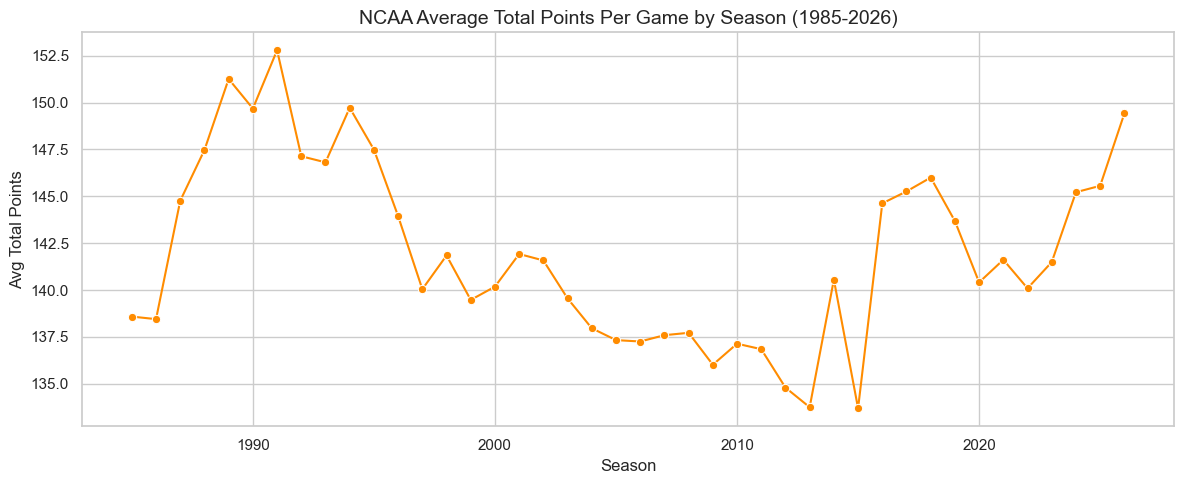

Era
1985-1999   145.2972
2000-2012   138.1445
2013-2026   142.2393
Name: TotalPoints, dtype: float64


C:\Users\jackh\AppData\Local\Temp\ipykernel_13760\3117837334.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(yearly_scores.groupby('Era')['TotalPoints'].mean())


In [7]:
df_regular['TotalPoints'] = df_regular['WScore'] + df_regular['LScore']
yearly_scores = df_regular.groupby('Season')['TotalPoints'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=yearly_scores, x='Season', y='TotalPoints', marker='o', color='darkorange', ax=ax)
ax.set_title('NCAA Average Total Points Per Game by Season (1985-2026)', fontsize=14)
ax.set_xlabel('Season')
ax.set_ylabel('Avg Total Points')
plt.tight_layout()
plt.show()

yearly_scores['Era'] = pd.cut(yearly_scores['Season'], bins=[1984, 1999, 2012, 2026],
                               labels=['1985-1999', '2000-2012', '2013-2026'])
print(yearly_scores.groupby('Era')['TotalPoints'].mean())

### 4.2 Class Imbalance Visualization

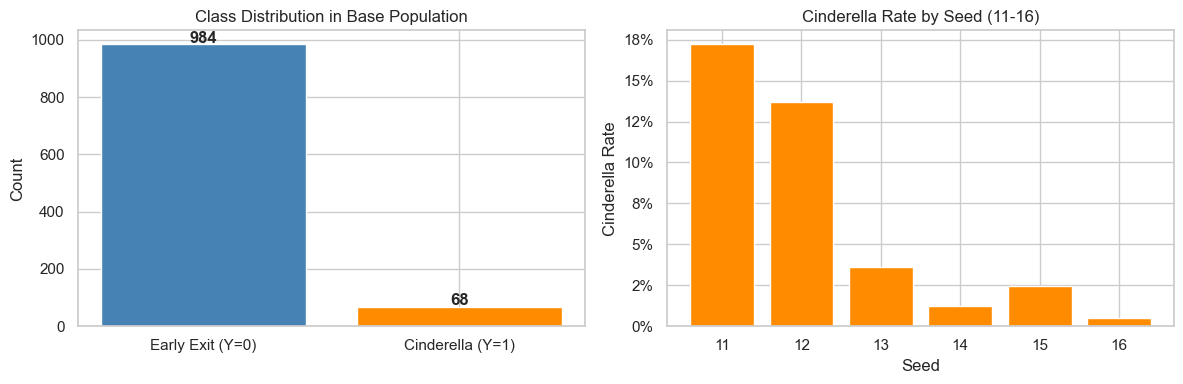

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df_base['Cinderella'].value_counts()
axes[0].bar(['Early Exit (Y=0)', 'Cinderella (Y=1)'], label_counts.values,
            color=['steelblue', 'darkorange'], edgecolor='white')
axes[0].set_title('Class Distribution in Base Population')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

seed_rate = df_base.groupby('SeedInt')['Cinderella'].mean()
axes[1].bar(seed_rate.index, seed_rate.values, color='darkorange', edgecolor='white')
axes[1].set_title('Cinderella Rate by Seed (11-16)')
axes[1].set_xlabel('Seed')
axes[1].set_ylabel('Cinderella Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

### 4.3 Tournament Upset Heatmap

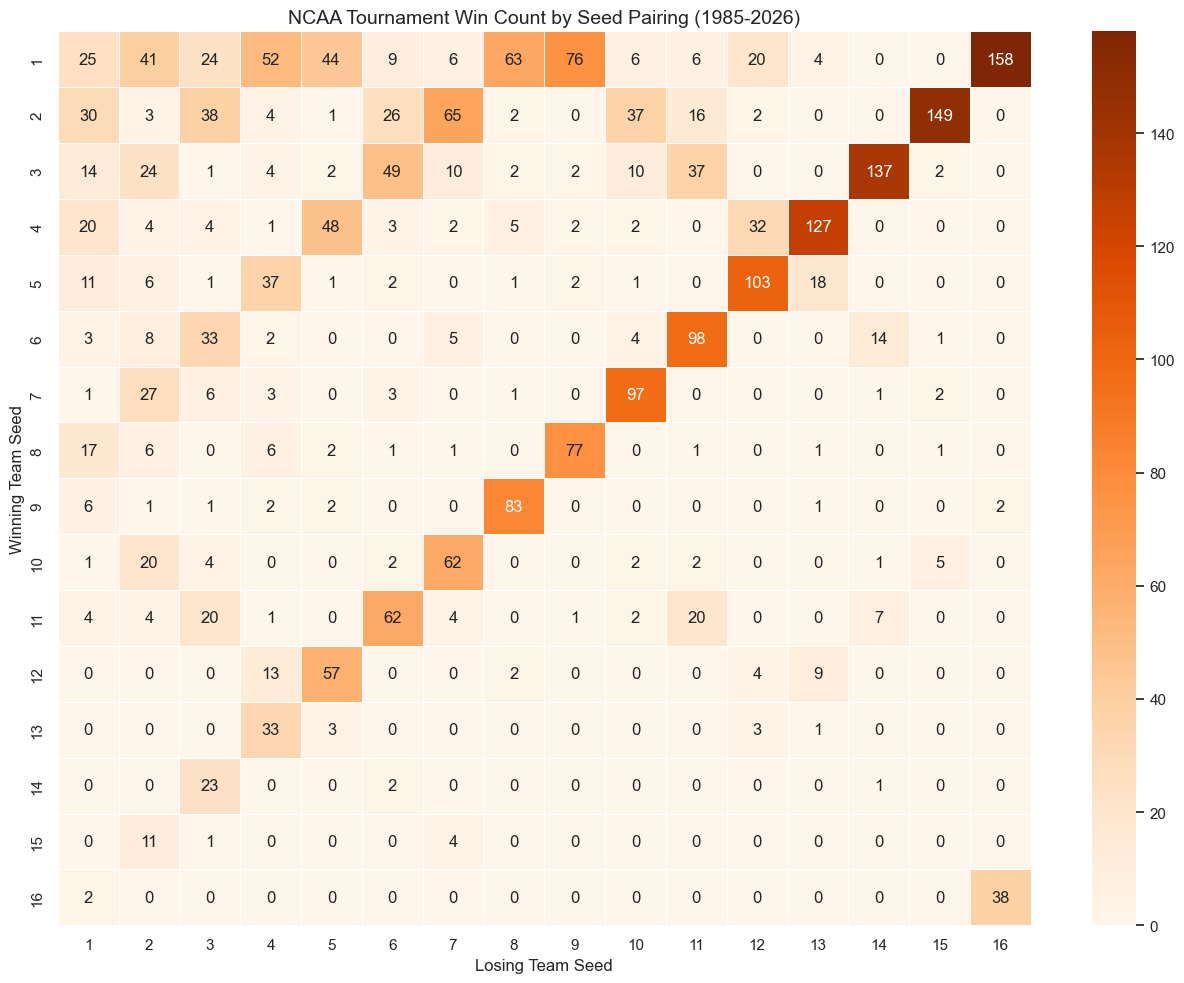

In [9]:
upset_matrix = pd.crosstab(df_tourney_seeded['WSeed'], df_tourney_seeded['LSeed'])

plt.figure(figsize=(13, 10))
sns.heatmap(upset_matrix, annot=True, fmt='d', cmap='Oranges', linewidths=0.4)
plt.title('NCAA Tournament Win Count by Seed Pairing (1985-2026)', fontsize=14)
plt.xlabel('Losing Team Seed')
plt.ylabel('Winning Team Seed')
plt.tight_layout()
plt.show()

---

## 5. Feature Engineering

We derive three basketball analytics features (the "Giant-Killer Footprint") from detailed regular-season box scores.

| Feature | Formula | Meaning |
|---|---|---|
| **Pace** | `(FGA + 0.475×FTA + TO − OR) / Games` | Slow pace reduces variance → upset potential |
| **ThreePointRate** | `FGA3 / FGA` | High 3P reliance = high-variance strategy |
| **ThreePointPct** | `FGM3 / FGA3` | Higher 3 point percentage increases score |

### 5.1 Build Per-Team Season Stats

In [10]:
w_stats = df_detailed.groupby(['Season', 'WTeamID']).agg(
    W_FGA=('WFGA', 'sum'), W_TO=('WTO', 'sum'), W_FTA=('WFTA', 'sum'),
    W_OR=('WOR', 'sum'), W_FGA3=('WFGA3', 'sum'), W_FGM3=('WFGM3', 'sum'),
    W_Games=('WScore', 'count')
).reset_index().rename(columns={'WTeamID': 'TeamID'})

l_stats = df_detailed.groupby(['Season', 'LTeamID']).agg(
    L_FGA=('LFGA', 'sum'), L_TO=('LTO', 'sum'), L_FTA=('LFTA', 'sum'),
    L_OR=('LOR', 'sum'), L_FGA3=('LFGA3', 'sum'), L_FGM3=('LFGM3', 'sum'),
    L_Games=('LScore', 'count')
).reset_index().rename(columns={'LTeamID': 'TeamID'})

team_stats = pd.merge(w_stats, l_stats, on=['Season', 'TeamID'], how='outer').fillna(0)

team_stats['TotalGames'] = team_stats['W_Games'] + team_stats['L_Games']
team_stats['TotalFGA']   = team_stats['W_FGA']   + team_stats['L_FGA']
team_stats['TotalTO']    = team_stats['W_TO']    + team_stats['L_TO']
team_stats['TotalFTA']   = team_stats['W_FTA']   + team_stats['L_FTA']
team_stats['TotalOR']    = team_stats['W_OR']    + team_stats['L_OR']
team_stats['TotalFGA3']  = team_stats['W_FGA3']  + team_stats['L_FGA3']
team_stats['TotalFGM3']  = team_stats['W_FGM3']  + team_stats['L_FGM3']

team_stats['TotalPoss']      = team_stats['TotalFGA'] + 0.475 * team_stats['TotalFTA'] + team_stats['TotalTO'] - team_stats['TotalOR']
team_stats['Pace']           = team_stats['TotalPoss'] / team_stats['TotalGames']
team_stats['ThreePointRate'] = team_stats['TotalFGA3'] / team_stats['TotalFGA']
team_stats['ThreePointPct']  = team_stats['TotalFGM3'] / team_stats['TotalFGA3']

df_features = team_stats[['Season', 'TeamID', 'Pace', 'ThreePointRate', 'ThreePointPct']].copy()
print(f'Feature table shape: {df_features.shape}')
df_features.head()

Feature table shape: (8346, 5)


,Season,TeamID,Pace,ThreePointRate,ThreePointPct
0,2003,1102,55.1616,0.5233,0.3756
1,2003,1103,70.9833,0.2878,0.3387
2,2003,1104,66.8339,0.3473,0.3201
3,2003,1105,77.1462,0.3371,0.3648
4,2003,1106,67.8563,0.3191,0.3462


### 5.2 Add Public Consensus Rankings (KenPom Day 133)

In [11]:
df_pre_tourney = df_massey[
    (df_massey['RankingDayNum'] == 133) &
    (df_massey['SystemName'] == 'POM')
].copy()

df_ranks = df_pre_tourney[['Season', 'TeamID', 'OrdinalRank']].rename(
    columns={'OrdinalRank': 'PreTourneyRank'}
)

print(f'Pre-tournament KenPom rankings available: {len(df_ranks):,} team-seasons')
df_ranks.head()

Pre-tournament KenPom rankings available: 7,989 team-seasons


,Season,TeamID,PreTourneyRank
127259,2003,1102,160
127260,2003,1103,163
127261,2003,1104,33
127262,2003,1105,307
127263,2003,1106,263


### 5.3 Assemble the Modeling Dataset

In [12]:
df_model = (
    df_base
    .merge(df_features, on=['Season', 'TeamID'], how='inner')
    .merge(df_ranks, on=['Season', 'TeamID'], how='inner')
    .dropna()
)

print(f'Final modeling dataset: {df_model.shape}')
print(f'Cinderella rate: {df_model["Cinderella"].mean():.2%}')
df_model.describe()

Final modeling dataset: (618, 8)
Cinderella rate: 6.63%


,Season,TeamID,SeedInt,Cinderella,Pace,ThreePointRate,ThreePointPct,PreTourneyRank
count,618.0000,618.0000,618.0000,618.0000,618.0000,618.0000,618.0000,618.0000
mean,2014.5307,1295.7249,13.5550,0.0663,68.4576,0.3522,0.3556,109.9660
std,6.9158,107.3652,1.7971,0.2491,3.3773,0.0552,0.0263,65.7660
min,2003.0000,1101.0000,11.0000,0.0000,54.1429,0.2168,0.2649,11.0000
25%,2009.0000,1209.5000,12.0000,0.0000,66.2201,0.3136,0.3373,58.0000
50%,2014.0000,1300.0000,14.0000,0.0000,68.3922,0.3504,0.3558,94.0000
75%,2021.0000,1393.0000,15.0000,0.0000,70.8586,0.3887,0.3745,148.0000
max,2026.0000,1474.0000,16.0000,1.0000,77.9352,0.5285,0.4417,318.0000


### 5.4 Cinderella Feature Profile

Average feature values by Cinderella label:
                    Pace  ThreePointRate  ThreePointPct  PreTourneyRank
Cinderella                                                             
Y=0 (Early Exit) 68.5108          0.3524         0.3557        113.4125
Y=1 (Cinderella) 67.7093          0.3501         0.3549         61.4634


C:\Users\jackh\AppData\Local\Temp\ipykernel_13760\952963995.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='Cinderella', y=feat,
C:\Users\jackh\AppData\Local\Temp\ipykernel_13760\952963995.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Early Exit', 'Cinderella'])
C:\Users\jackh\AppData\Local\Temp\ipykernel_13760\952963995.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='Cinderella', y=feat,
C:\Users\jackh\AppData\Local\Temp\ipykernel_13760\952963995.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. 

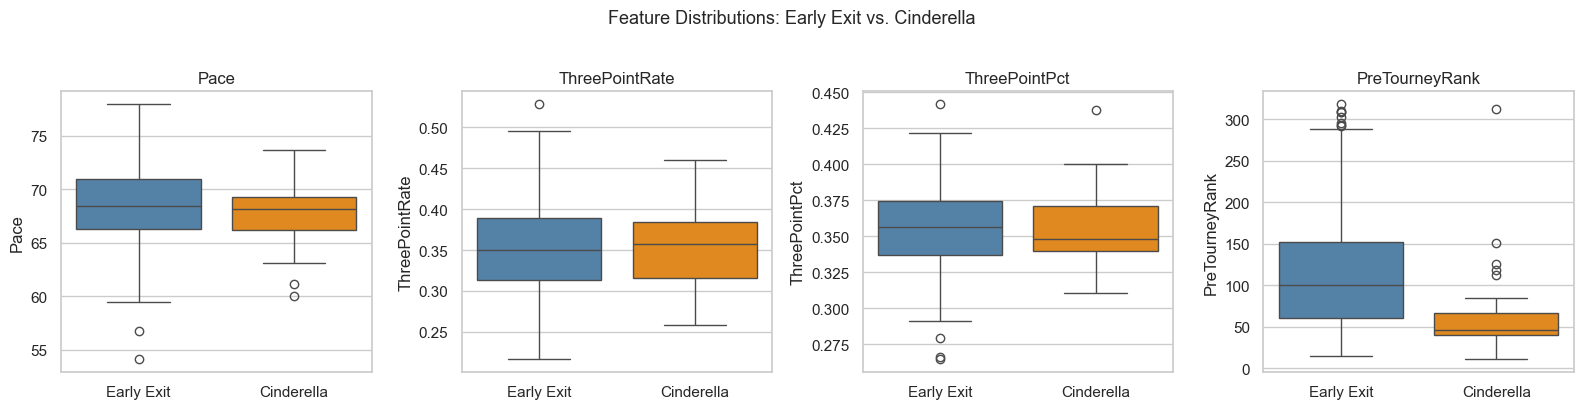

In [13]:
profile = df_model.groupby('Cinderella')[['Pace', 'ThreePointRate', 'ThreePointPct', 'PreTourneyRank']].mean()
print('Average feature values by Cinderella label:')
print(profile.rename(index={0: 'Y=0 (Early Exit)', 1: 'Y=1 (Cinderella)'}).to_string())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, ['Pace', 'ThreePointRate', 'ThreePointPct', 'PreTourneyRank']):
    sns.boxplot(data=df_model, x='Cinderella', y=feat,
                palette={'0': 'steelblue', '1': 'darkorange'}, ax=ax)
    ax.set_xticklabels(['Early Exit', 'Cinderella'])
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('Feature Distributions: Early Exit vs. Cinderella', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Models

We evaluate several classification models to predict Cinderella anomalies. Our evaluation uses a chronological split where we train on data through 2021 and test on seasons 2022 through 2025. We apply SMOTE to the training set to handle class imbalance. The models include a KenPom baseline and several machine learning candidates like Random Forest and Gradient Boosting. We prioritize the F1-Score to balance precision and recall in detecting these rare events.

In [19]:
FEATURE_COLS = ['SeedInt', 'Pace', 'ThreePointRate', 'ThreePointPct', 'PreTourneyRank']
TARGET_COL   = 'Cinderella'

# Chronological split: train on the past, test on the most recent seasons.
train_df = df_model[df_model['Season'] <= 2021]
test_df  = df_model[df_model['Season'] >= 2022]

X_train, y_train = train_df[FEATURE_COLS].values, train_df[TARGET_COL].values
X_test,  y_test  = test_df[FEATURE_COLS].values,  test_df[TARGET_COL].values

# Season labels for the training rows -> used for leakage-free grouped CV in
# Sections 7 and 8.
groups_train = train_df['Season'].values

# IMPORTANT: SMOTE is only ever applied to TRAINING data. The test set stays
# untouched so that test metrics reflect the real, imbalanced distribution.
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Train before SMOTE:   {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Train after SMOTE:    {dict(zip(*np.unique(y_train_res, return_counts=True)))}')
print(f'Test set (untouched): {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train before SMOTE:   {np.int64(0): np.int64(447), np.int64(1): np.int64(33)}
Train after SMOTE:    {np.int64(0): np.int64(447), np.int64(1): np.int64(447)}
Test set (untouched): {np.int64(0): np.int64(130), np.int64(1): np.int64(8)}


In [20]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

candidate_models = {
    'Baseline (KenPom Only)': LogisticRegression(random_state=42),
    'Logistic Regression':    LogisticRegression(random_state=42),
    'Random Forest':          RandomForestClassifier(random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(random_state=42),
}

results = {}
rank_idx = FEATURE_COLS.index('PreTourneyRank')
for name, model in candidate_models.items():
    if name == 'Baseline (KenPom Only)':
        model.fit(X_train_sc[:, [rank_idx]], y_train_res)
        preds = model.predict(X_test_sc[:, [rank_idx]])
    else:
        model.fit(X_train_sc, y_train_res)
        preds = model.predict(X_test_sc)
    results[name] = {
        'F1':        f1_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall':    recall_score(y_test, preds),
    }

results_df = pd.DataFrame(results).T
print(results_df.to_string())

                           F1  Precision  Recall
Baseline (KenPom Only) 0.1667     0.1000  0.5000
Logistic Regression    0.1786     0.1042  0.6250
Random Forest          0.2105     0.1818  0.2500
Gradient Boosting      0.1739     0.1333  0.2500


---

## 7. Model Tuning

Based on initial results, the Random Forest classifier showed the highest potential for detecting Cinderellas. We perform a grid search over key hyperparameters including forest size, tree depth, and class weighting to optimize the model for the F1-score. This step ensures we maximize our ability to flag anomalies while maintaining reasonable precision.

In [23]:
# SMOTE + scaling + RF as ONE pipeline. With SMOTE inside the pipeline,
# GridSearchCV applies it ONLY to the training side of each fold -- the
# validation fold stays real and unseen, so the CV F1 is honest.
pipe = ImbPipeline(steps=[
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(random_state=42)),
])

param_grid = {
    'rf__n_estimators':     [100, 200, 300],
    'rf__max_depth':        [3, 5, 7],
    'rf__min_samples_leaf': [2, 5, 10],
    'rf__class_weight':     ['balanced', 'balanced_subsample', None],
}

# Stratified, season-grouped folds: no season appears in both train and
# validation within a fold (prevents same-season leakage), while keeping the
# rare positive class spread across folds. This matches our chronological
# train/test design so the CV score actually tracks test performance.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipe,
    param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

# Fit on RAW (un-resampled, un-scaled) training data -- the pipeline handles
# SMOTE and scaling internally, fold by fold.
grid_search.fit(X_train, y_train, groups=groups_train)

# Evaluate on the RAW, untouched test set (pipeline scales it with the
# train-fitted scaler; SMOTE is skipped at predict time).
preds = grid_search.predict(X_test)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Honest CV F1 (season-grouped): {grid_search.best_score_:.4f}')
print(f'Test F1:        {f1_score(y_test, preds):.4f}')
print(f'Test Precision: {precision_score(y_test, preds):.4f}')
print(f'Test Recall:    {recall_score(y_test, preds):.4f}')

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 3, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 200}
Honest CV F1 (season-grouped): 0.2898
Test F1:        0.2273
Test Precision: 0.1389
Test Recall:    0.6250


---

## 8. Final Model

We select the best-tuned Random Forest model as our final Cinderella classifier. After retraining on the full resampled training set, we evaluate its performance on the held-out test years (2022–2025). We analyze the results through a confusion matrix and feature importance rankings, comparing the final F1-score against the KenPom baseline.

In [25]:
# Best pipeline from the season-grouped grid search above.
best_model = grid_search.best_estimator_

# --- Threshold tuning WITHOUT leakage ---------------------------------------
# Get OUT-OF-FOLD probabilities: each training row is scored by a model that
# never saw it during fitting. The threshold chosen on these honest
# probabilities generalizes; a threshold tuned on in-sample training
# predictions does not (the RF near-perfectly separates its own train data).
oof_probs = cross_val_predict(
    best_model, X_train, y_train,
    cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42),
    groups=groups_train,
    method='predict_proba', n_jobs=-1,
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_probs)
f1_scores = np.divide(2 * precision * recall, precision + recall,
                      out=np.zeros_like(precision), where=(precision + recall) != 0)
# thresholds has one fewer element than precision/recall; drop the last point.
best_idx = int(np.argmax(f1_scores[:-1]))
best_threshold = thresholds[best_idx]

# Refit the chosen pipeline on the full training set, then score the test set
# ONCE at the tuned threshold.
best_model.fit(X_train, y_train)
y_test_probs = best_model.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_probs >= best_threshold).astype(int)

print(f'Best Parameters:           {grid_search.best_params_}')
print(f'Honest CV F1 (grouped):    {grid_search.best_score_:.4f}')
print(f'Tuned threshold (OOF):     {best_threshold:.3f}')
print(f'Test F1:        {f1_score(y_test, y_test_pred):.4f}')
print(f'Test Precision: {precision_score(y_test, y_test_pred):.4f}')
print(f'Test Recall:    {recall_score(y_test, y_test_pred):.4f}')

Best Parameters:           {'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 3, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 200}
Honest CV F1 (grouped):    0.2898
Tuned threshold (OOF):     0.541
Test F1:        0.2273
Test Precision: 0.1389
Test Recall:    0.6250


Final Model Classification Report (Test Set):
              precision    recall  f1-score   support

  Early Exit       0.97      0.76      0.85       130
  Cinderella       0.14      0.62      0.23         8

    accuracy                           0.75       138
   macro avg       0.55      0.69      0.54       138
weighted avg       0.92      0.75      0.82       138

Baseline KenPom F1: 0.1667
Final Model F1:     0.2273
Relative F1 Improvement: +36.34%


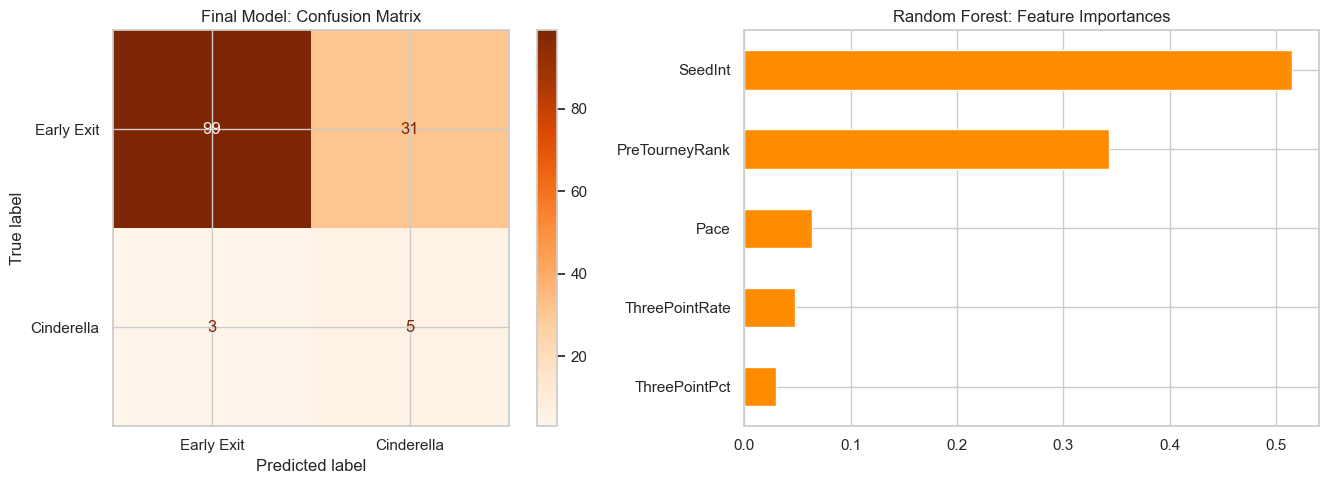

In [26]:
# best_model is the full pipeline (SMOTE + scaler + RF). Predict on the RAW
# test set -- do NOT pass X_test_sc, which is already scaled and would be
# scaled a SECOND time inside the pipeline (a silent bug that corrupts every
# test feature value). Use the SAME tuned threshold as Section 8 for consistency.
y_pred_final = (best_model.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)

print("Final Model Classification Report (Test Set):")
print(classification_report(y_test, y_pred_final, target_names=['Early Exit', 'Cinderella']))

final_f1 = f1_score(y_test, y_pred_final)
baseline_f1 = 0.1667  # KenPom-only baseline from Section 6
improvement = (final_f1 - baseline_f1) / baseline_f1

print(f"Baseline KenPom F1: {baseline_f1:.4f}")
print(f"Final Model F1:     {final_f1:.4f}")
print(f"Relative F1 Improvement: {improvement:+.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Early Exit', 'Cinderella'],
    cmap='Oranges', ax=axes[0]
)
axes[0].set_title('Final Model: Confusion Matrix')

# Feature importances live on the RF step INSIDE the pipeline, not on the
# pipeline object itself.
rf_step = best_model.named_steps['rf']
importances = pd.Series(rf_step.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind='barh', color='darkorange', ax=axes[1])
axes[1].set_title('Random Forest: Feature Importances')

plt.tight_layout()
plt.show()